In [ ]:
import os
import paths

os.chdir(paths.PROJECT_ROOT)

import utils_inverse
import utils_plotting

%load_ext autoreload
%autoreload 2

# Main text figures

Each cell writes its figure into `Figures/`. Figure 1 is a schematic assembled outside Python; this notebook produces its three source panels.

## Figure 1 source panels

Panels (a)-(c) of the optimization-overview schematic, combined by hand into `fig01_optimization.pdf`.

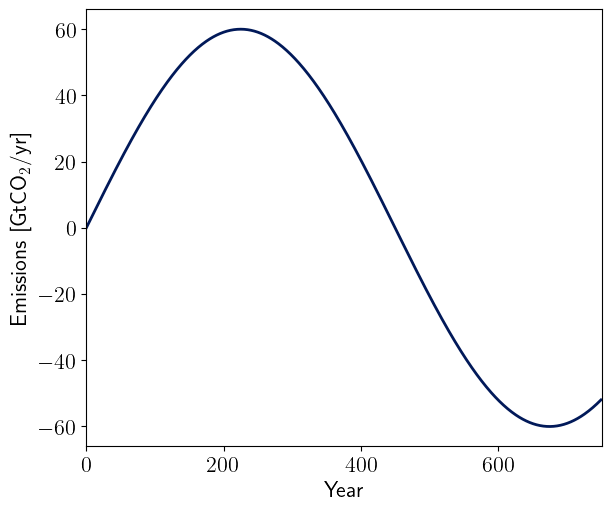

In [2]:
res = utils_inverse.load_inverse_ckpt('checkpoints/co2/inverse_sine_tier1_co2_only.pkl')
utils_plotting.plot_fig01_init_emissions(res, save=True)

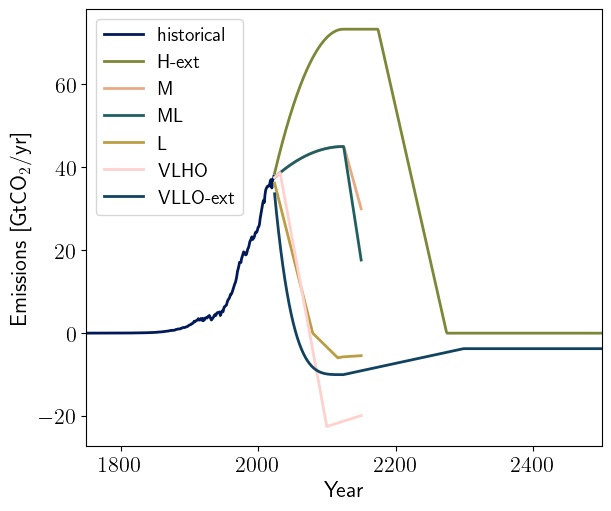

In [3]:
fig1_data = utils_inverse.load_fig1_tier1_scenarios()
utils_plotting.plot_fig01_tier1_scenarios(**fig1_data, save=True)

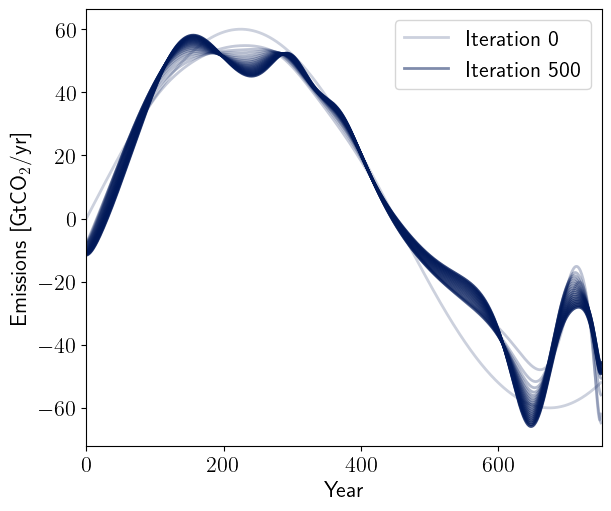

In [4]:
utils_plotting.plot_fig01_emissions_updates(res, save=True)

## Figure 2: optimization of a single CO2-only scenario

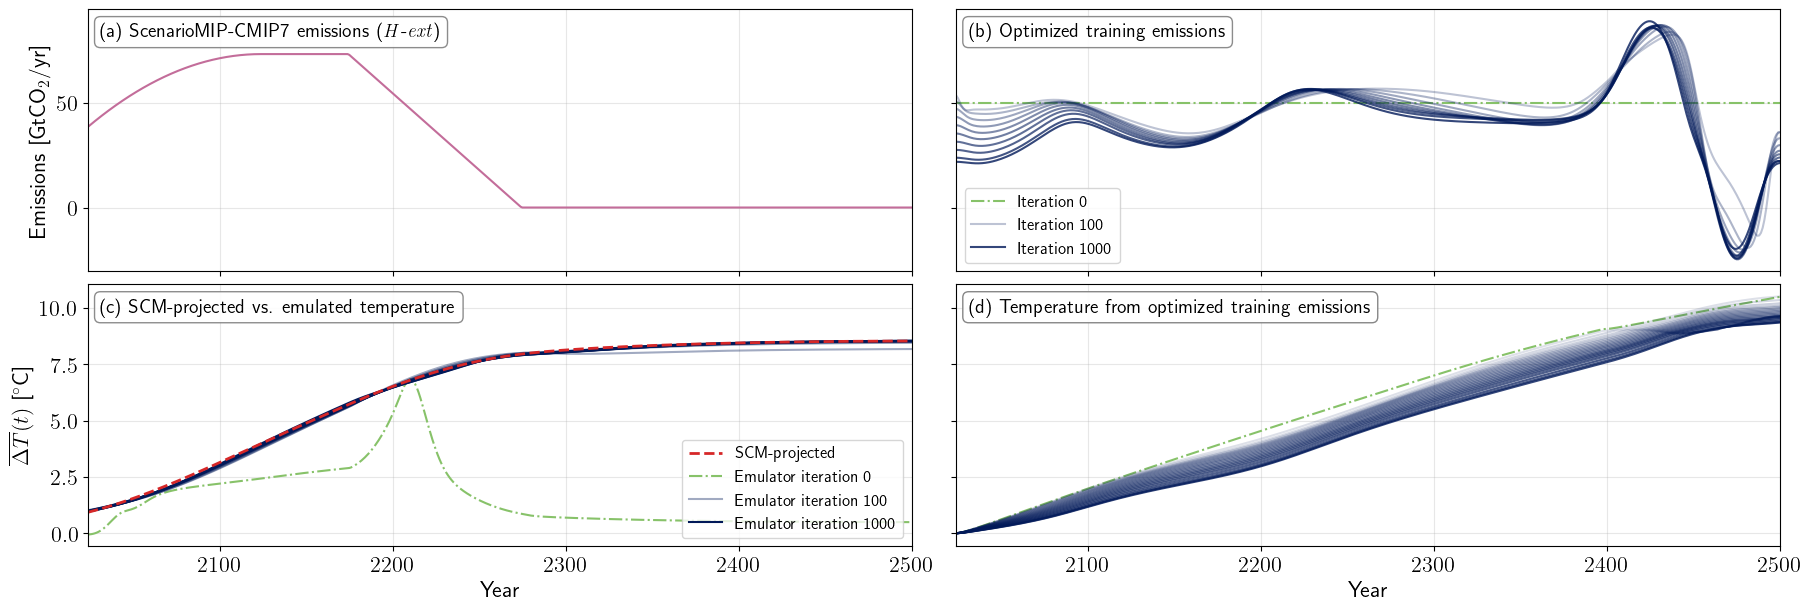

In [5]:
fig2_data = utils_inverse.load_fig2_data()
utils_plotting.plot_fig02_co2_example(
    fig2_data['target_emissions'], fig2_data['years'], fig2_data['opt_emissions'],
    fig2_data['opt_temp'], fig2_data['opt_results'],
    save=True, save_path='Figures/fig02_co2_example.pdf',
)

## Figure 3: error spread across single-forcing experiments

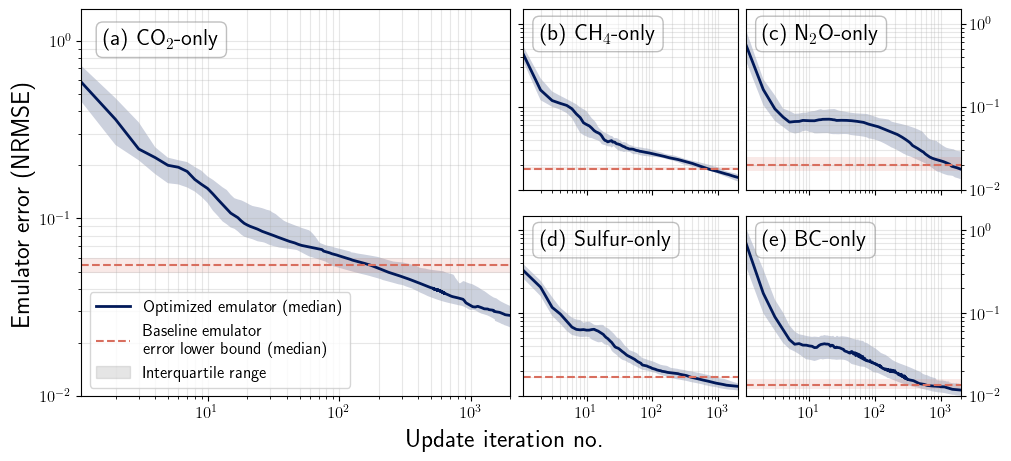

In [6]:
fig3_data = utils_inverse.load_fig3_single_forcing_data()
fig3_seed_data = utils_inverse.load_fig3_single_forcing_data_seed_sweep()
utils_plotting.plot_fig03_single_forcing(
    fig3_data['results_inverse'], fig3_data['results_baseline'], fig3_data['labels'],
    seed_errors_list=fig3_seed_data['seed_errors_list'],
    seed_baseline_error_list=fig3_seed_data['seed_baseline_error_list'],
    save=True,
)

## Figure 4: performance relative to baseline across evaluation sets

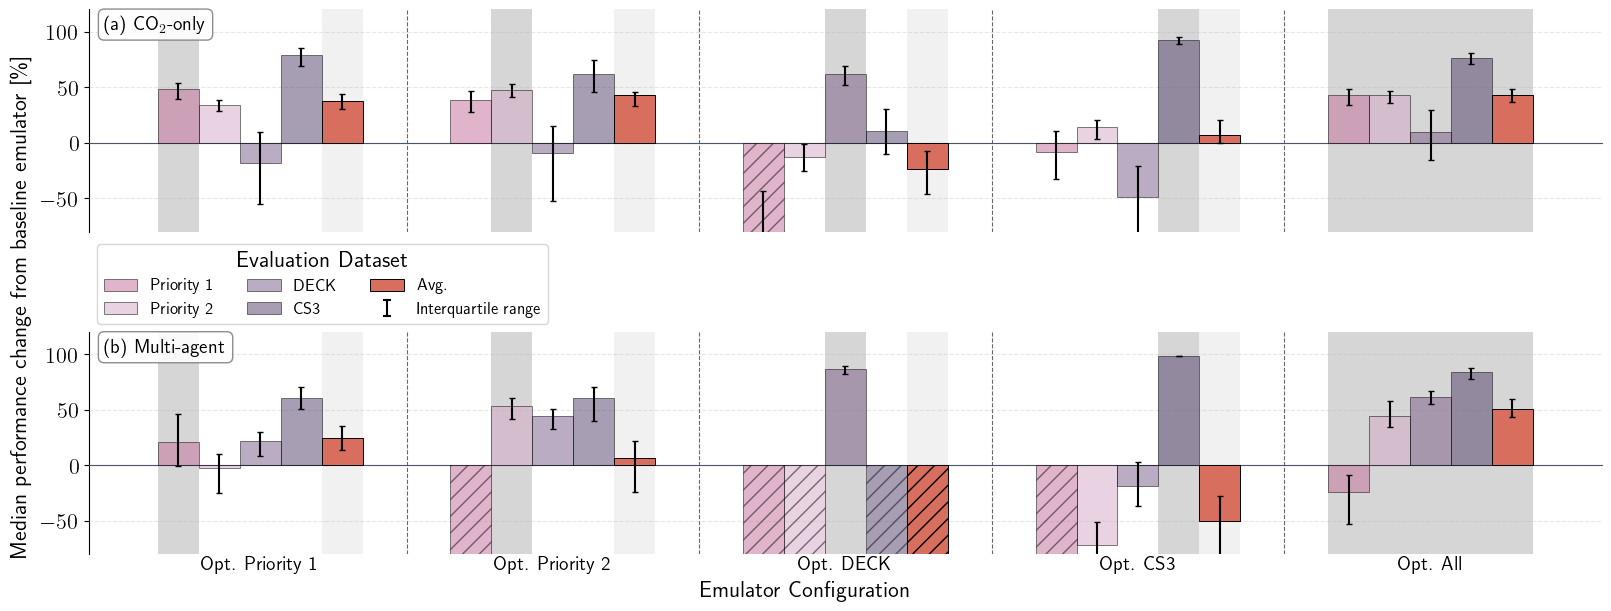

In [7]:
import pickle

fig4_data = utils_inverse.load_fig4_data()

with open('data/SI_results/seed_uncertainty/fig4_seed_spread_co2_only.pkl', 'rb') as f:
    _spread_co2 = pickle.load(f)
with open('data/SI_results/seed_uncertainty/fig4_seed_spread_all_agents_smooth.pkl', 'rb') as f:
    _spread_multi = pickle.load(f)

_seed_baseline = [[_spread_co2[s]['baseline'] for s in sorted(_spread_co2)],
                  [_spread_multi[s]['baseline'] for s in sorted(_spread_multi)]]
_seed_optimized = [[_spread_co2[s]['optimal'] for s in sorted(_spread_co2)],
                   [_spread_multi[s]['optimal'] for s in sorted(_spread_multi)]]

utils_plotting.plot_fig04_scm_summary(
    **fig4_data, titles=None, save=True,
    seed_baseline_results_list=_seed_baseline,
    seed_optimized_results_list=_seed_optimized,
)

## Figure 5: multi-forcing error and optimized emissions

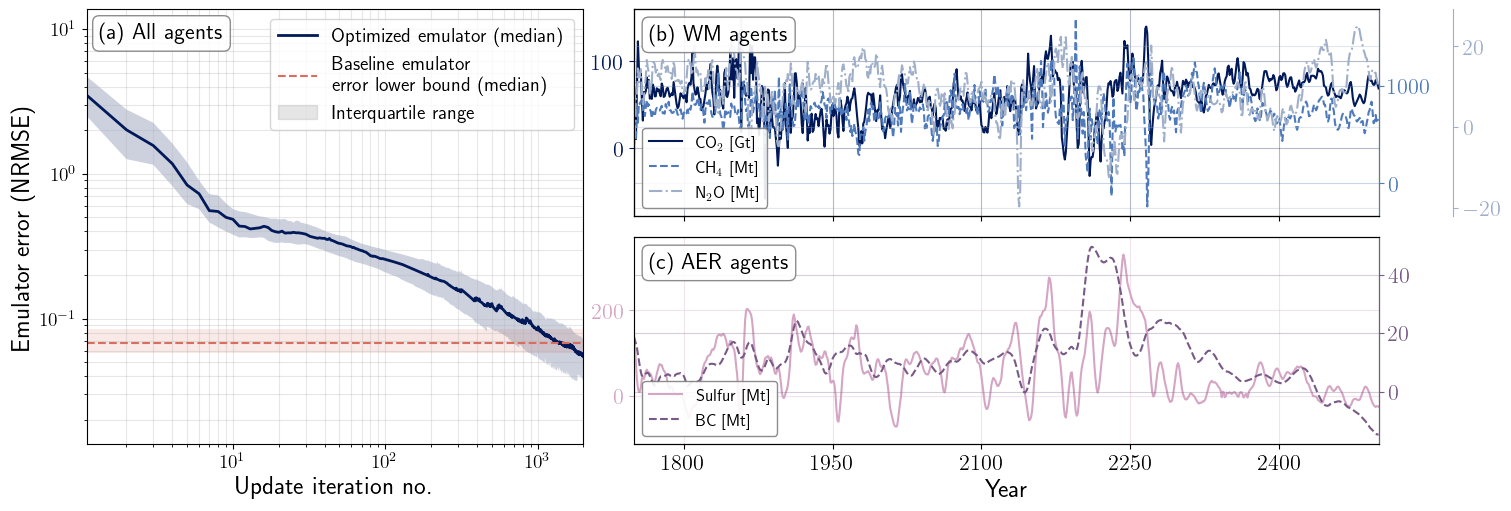

In [8]:
fig5_data = utils_inverse.load_fig5_multi_forcing_data()
fig5_seed_data = utils_inverse.load_fig5_multi_forcing_data_seed_sweep()
utils_plotting.plot_fig05_multi_forcing(
    fig5_data['results'], fig5_data['baseline_error'],
    seed_errors=fig5_seed_data['seed_errors'],
    seed_baseline_errors=fig5_seed_data['seed_baseline_errors'],
    save=True,
)

## Figure 6: performance on structurally distinct forcing scenarios

load_fig6_data: seed spread loaded (50 seeds) -> median + IQR


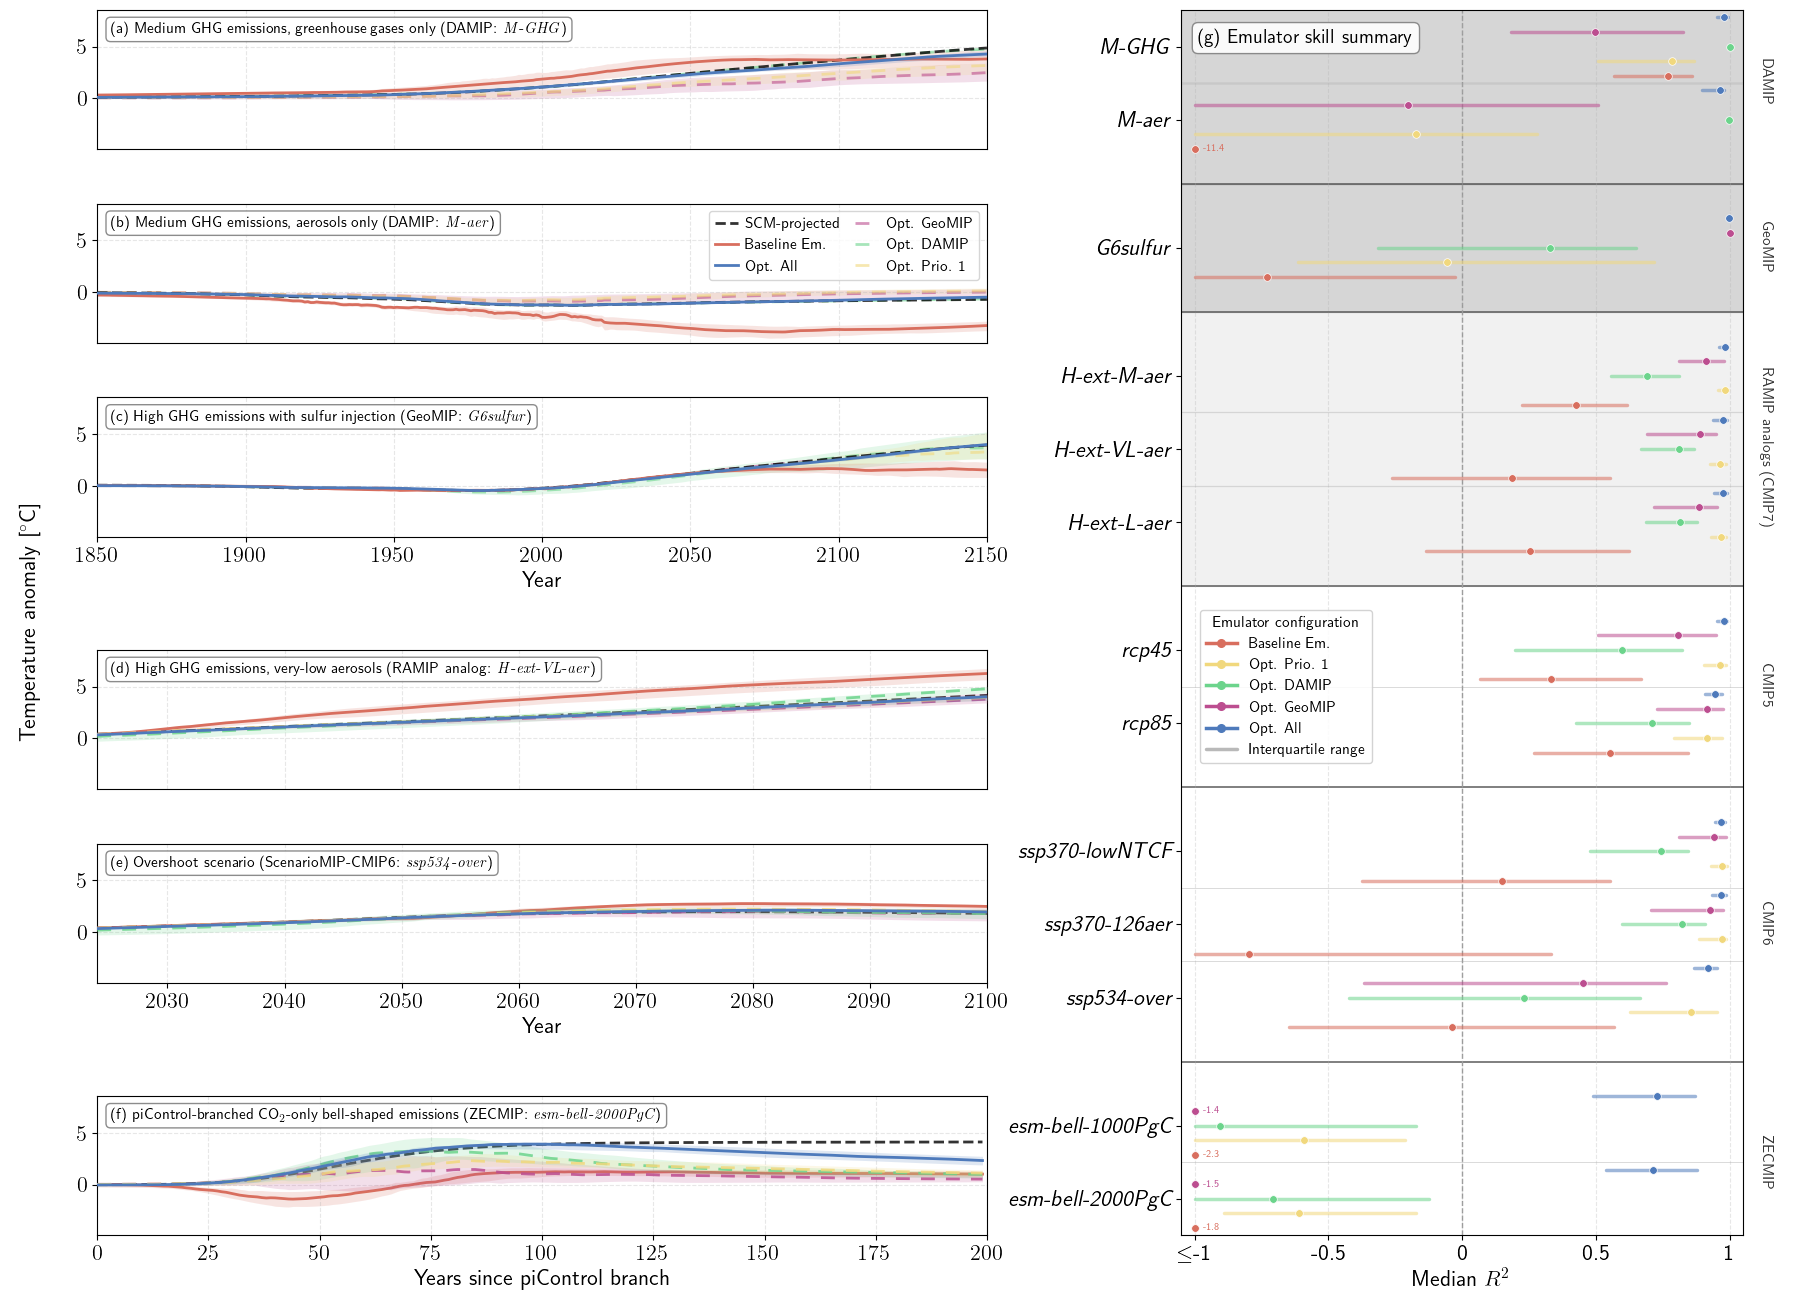

In [9]:
fig6_data = utils_inverse.load_fig6_data()
fig6_ood_data = utils_inverse.load_fig6_ood_data()
utils_plotting.plot_fig06_individual_effects(
    **fig6_data, **fig6_ood_data, ppt=False, save=True,
    figname='fig06_individual_effects',
)

## Figure 7: MESM (EMIC) zonal-emulator summary

(<Figure size 1400x676.875 with 5 Axes>,
 {'Top1': <Axes: label='Top1', ylabel='Emissions [GtCO$_2$/yr]'>,
  'Top2': <Axes: label='Top2'>,
  'Bottom': <Axes: label='Bottom', xlabel='Scenario', ylabel='Median performance change\nfrom baseline emulator [\\%]'>})

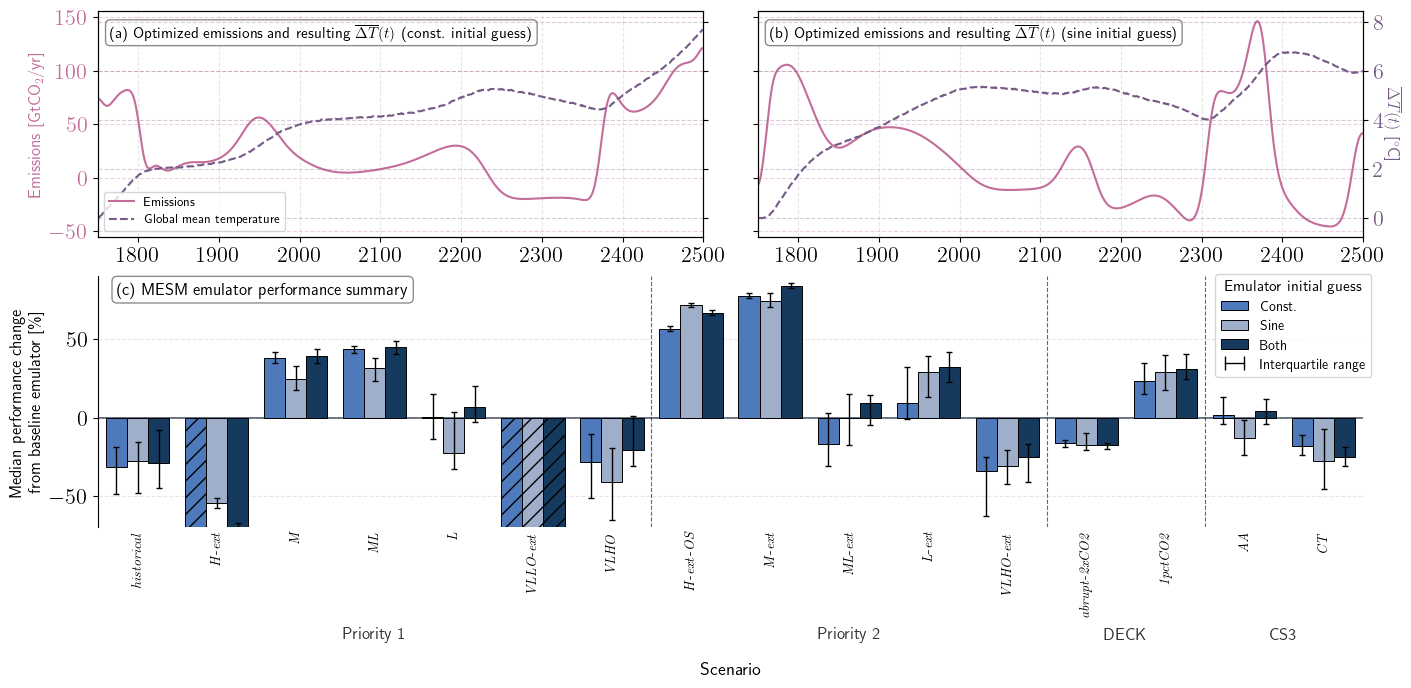

In [10]:
utils_plotting.plot_fig07_emic_summary(save=True)